# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning



_Fill in your group number **from Brightspace**, names, and student numbers._
    
| Group          | 71      |
|----------------|---------|
| Bente van Geen | 6213278 |
| Femke Knibbe   | 6180280 |
| Lauren But     | XXXXXXX |
| Henno Kruis    | 5988063 |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [2]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        actions = agent.get_valid_actions(maze)

        # random.choice assumes at least one element in the list
        if not actions:
            return None

        return random.choice(actions)

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        actions = agent.get_valid_actions(maze)
        state = agent.get_state(maze)

        if not actions:
            return None


        if random.random() < eps:
            return random.choice(actions)


        q_values = [self.q_table.get_q(state, a) for a in actions]
        max_q = max(q_values)

        best_actions = [action for action, q in zip(actions, q_values) if q == max_q]
        return random.choice(best_actions)

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        actions = agent.get_valid_actions(maze)
        state = agent.get_state(maze)

        if not actions:
            return None

        q_values = np.array([self.q_table.get_q(state, a) for a in actions], dtype=float)

        if temperature <= 0:
            max_q = np.max(q_values)
            best_actions = [action for action, q in zip(actions, q_values) if q == max_q]
            return random.choice(best_actions)

        shifted_q = q_values - np.max(q_values)
        exp_values = np.exp(shifted_q / temperature)
        probs = exp_values / np.sum(exp_values)

        return np.random.choice(actions, p=probs)


Discussion
### *Random*

The random exploration strategy selects an action uniformly at random from the set of all valid actions available. Every action has equal probability of being chosen.

This strategy is useful in the early stages of learning because it guarantees full exploration of the maze. However, it does not take into account any learned information. This makes it that 'bad' actions will still be chosen over time.

### *ε-greedy*

The ε-greedy strategy balances exploration and exploitation by introducing a probability ε. A random number between 0 and 1:

If the number is less than ε, a random action is selected (exploration) otherwise the action with the highest Q-value is selected (exploitation)

This approach allows the agent to gradually shift from exploration to exploitation.

One drawback during exploration, actions are still chosen uniformly at random, making it such that poor actions are explored as often as good actions.

### *Boltzmann (Softmax)*

The Boltzmann exploration strategy assigns probabilities to actions based on their Q-values using a softmax function. Actions with higher Q-values are more likely to be selected, but lower-valued actions still have a chance depending on the temperature parameter T.

With high temperature the probabilities are more uniform which means more exploration.
With low temperature probabilities concentrate on the best action which means more exploitation

Hyper-parameter choices
ε (epsilon): Initially set between 0.1 and 0.3 to ensure sufficient exploration. Optionally decayed over time to reduce randomness as learning progresses.
Temperature (T): Started at a higher value (T ~ 1.0) and gradually decreased.

These values were chosen to ensure that the agent explores enough early on while still allowing convergence later.

#### Question 2

In [3]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
# learner = QLearning(q_table, params)

### Agent cycle

In [4]:
episode_lengths = []
episode_rewards = []
n_episodes = 300
max_steps = 1000

for episode in tqdm(range(n_episodes)):

    agent.reset()
    done = False
    episode_reward = 0

    while not done and agent.nr_of_actions_since_reset < max_steps:

        state = agent.get_state(maze)
        action = exploration_strategy.boltzmann(agent, maze, temperature=1.0)
        next_state, reward, done = agent.step(action, maze)
        # learner.learn(state, action, reward, next_state)
        episode_reward += reward

    episode_lengths.append(agent.nr_of_actions_since_reset)
    episode_rewards.append(episode_reward)

print(f"Episodes completed: {len(episode_lengths)}, total steps: {sum(episode_lengths)}")
# print(f"Episode rewards: {episode_rewards}")

100%|██████████| 300/300 [00:06<00:00, 48.92it/s]

Episodes completed: 300, total steps: 245378


The cycle runs for a fixed number of episodes n_episodes. Each episode represents one full attempt by the agent to find the goal.
At the start of each episode the agent is reset to its initial position. This is necessary to ensure each episode is an independent trial.
Within each episode, the agent repeatedly selects an action using the chosen exploration strategy, and observes the resulting next state and reward.
The episode ends when one of two conditions is met: the agent reaches the goal, or it exceeds *max_steps* steps. The *max_steps* limit is necessary because, especially early in training when the Q-table is uninformed, the agent may traverse without ever finding the goal. Without this limit a single episode could run forever, making the overall training infeasible.
At the end of each episode the total reward and number of steps are recorded. These are used to track whether the agent is improving over time. A well-learning agent should show increasing rewards and decreasing episode lengths as training progresses, however since we have not implemented the learner methods this should not show up.

#### Question 3

In [5]:
def run_agent(maze, agent, exploration_strategy, n_episodes, max_steps, max_total_steps):

    ep_lengths = []
    ep_rewards = []
    total_steps = 0

    for episode in tqdm(range(n_episodes)):
        if total_steps >= max_total_steps:
            break

        agent.reset()
        done = False
        episode_reward = 0

        while not done and agent.nr_of_actions_since_reset < max_steps:
            if total_steps >= max_total_steps:
                break

            state = agent.get_state(maze)
            action = exploration_strategy.boltzmann(agent, maze, temperature=1.0)
            next_state, reward, done = agent.step(action, maze)
            # learner.learn(state, action, reward, next_state)
            episode_reward += reward
            total_steps += 1

        ep_lengths.append(agent.nr_of_actions_since_reset)
        ep_rewards.append(episode_reward)
    return ep_lengths, ep_rewards

episode_lengths, episode_rewards = run_agent(maze, agent, exploration_strategy, n_episodes=300, max_steps=1000, max_total_steps=30000)

print(f"Episodes completed: {len(episode_lengths)}, total steps: {sum(episode_lengths)}")
print(f"Episode rewards: {episode_rewards}")

 12%|█▏        | 37/300 [00:00<00:05, 51.79it/s]

Episodes completed: 37, total steps: 30000
Episode rewards: [0, 0, 0, 10, 0, 0, 0, 10, 10, 0, 0, 0, 10, 0, 10, 10, 0, 10, 0, 0, 0, 0, 0, 0, 10, 10, 0, 10, 0, 10, 10, 0, 0, 0, 0, 0, 0]



The stopping criterion was implemented by maintaining a ***total_steps*** counter that increments by 1 after every action taken across all episodes. The criterion is checked in two places: before starting a new episode (to avoid beginning an episode that cannot complete), and inside the step loop (to stop mid-episode the moment the ***max_total_steps*** is reached). It can also be observed that in theory the total amount of steps across all episodes would be 300.000 (300 episodes with 1000 steps), thus the stopping criterion is the 30000 steps allowed to take

#### Question 4

 24%|██▍       | 72/300 [00:01<00:04, 48.62it/s]


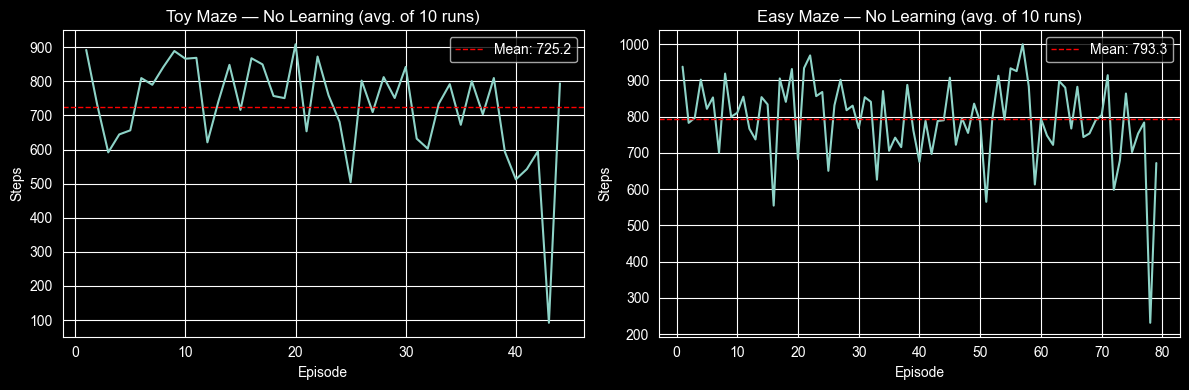

In [6]:
def average_runs(maze_path, reward_x, reward_y, start_x, start_y,
                 n_runs=10, n_episodes=300, max_steps=1000, max_total_steps=30000):
    all_lengths = []

    for _ in range(n_runs):
        maze = Maze(maze_path)
        maze.set_reward(x=reward_x, y=reward_y, reward=10)
        maze.set_terminal(x=reward_x, y=reward_y)
        agent = Agent(start_x=start_x, start_y=start_y)
        states = maze.get_all_states()
        actions = [Action(a) for a in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)

        lengths, _ = run_agent(maze, agent, exploration_strategy,
                            n_episodes, max_steps, max_total_steps)
        all_lengths.append(lengths)

    #Pad all the shorter runs such that it can be visually represented in the plots
    max_len = max(len(r) for r in all_lengths)
    padded = np.full((n_runs, max_len), np.nan)
    for i, r in enumerate(all_lengths):
        padded[i, :len(r)] = r

    avg = np.nanmean(padded, axis=0)
    return avg


avg_toy  = average_runs("./../data/toy_maze.txt",  reward_x=9, reward_y=9, start_x=0, start_y=0)
avg_easy = average_runs("./../data/easy_maze.txt", reward_x=9, reward_y=9, start_x=0, start_y=0,
                        max_total_steps=60000)  # larger maze needs more steps


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, avg, title in zip(axes, [avg_toy, avg_easy], ["Toy Maze", "Easy Maze"]):
    ax.plot(range(1, len(avg) + 1), avg, linewidth=1.5)
    ax.axhline(np.nanmean(avg), color='red', linestyle='--', linewidth=1, label=f'Mean: {np.nanmean(avg):.1f}')
    ax.set_xlabel("Episode")
    ax.set_ylabel("Steps")
    ax.set_title(f"{title} — No Learning (avg. of 10 runs)")
    ax.legend()

plt.tight_layout()
plt.show()

Runs stop at max_total_steps, not at a fixed episode count, so different runs may complete a different number of episodes. Shorter runs are padded with NaN and np.nanmean is used so the average is only computed over runs that actually reached that episode, keeping the plot meaningful rather than dragging the average down artificially.
### plots:
The average steps per episode should show no downward trend. The line stays flat or noisy around the mean for both mazes. This is expected because the Q-table is never updated, so the agent has no memory. Every episode starts with the same all-zero Q-table, making Boltzmann exploration effectively random every time. The easy maze will show higher and more variable step counts than the toy maze simply because it is larger (25×15 vs 10×10) and the goal is harder to stumble upon by chance.



#### Question 5

In [7]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action, next_state: State, reward: int, done: bool) -> None:

        learning_rate = self.params["lr"]
        discount_factor = self.params["gamma"]

        current_q = self.q_table.get_q(state, action)

        if done or len(possible_actions) == 0:
            target = reward
        else:
            best_q = max(self.q_table.get_q(next_state, next_action) for next_action in possible_actions)
            target = reward + discount_factor * best_q

        new_q = current_q + learning_rate * (target - current_q)
        self.q_table.set_q(state, action, new_q)

In [8]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State,
              next_action: Action, reward: float, done: bool) -> None:

        learning_rate = self.params["lr"]
        discount_factor = self.params["gamma"]

        current_q = self.q_table.get_q(state, action)

        if done or next_action is None:
            target = reward
        else:
            next_q = self.q_table.get_q(next_state, next_action)
            target = reward + discount_factor * next_q

        new_q = current_q + learning_rate * (target - current_q)
        self.q_table.set_q(state, action, new_q)

#### Q-Learning


Q-Learning updates the Q-value of the current state-action pair using the Bellman equation:
Q(s,a) ← Q(s,a) + α(r + γ·max Q(s',a') − Q(s,a)).
The key term is max Q(s', a_max), the update always assumes the best possible action will be chosen from the next state. The result is that Q-Learning learns the optimal policy directly. The trade-off is that it can be less stable early in training.

#### SARSA
SARSA updates using:
Q(s,a) ← Q(s,a) + α(r + γ·Q(s',a') − Q(s,a)).
Here a' is the action the agent actually takes in the next state. This means if the agent uses ε-greedy, SARSA accounts for the fact that it will sometimes take random actions.





#### Question 6

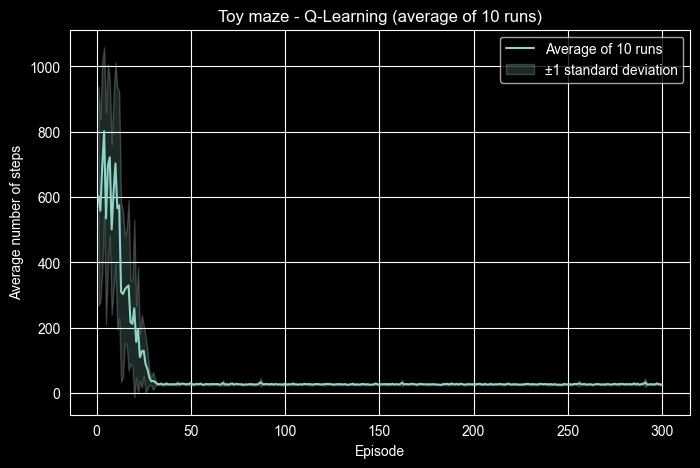

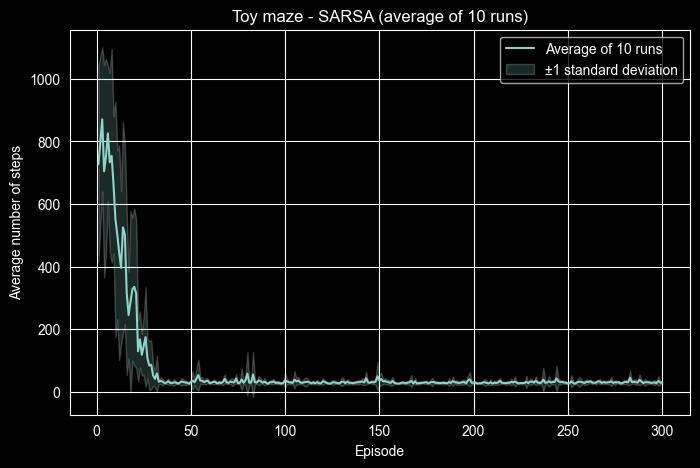

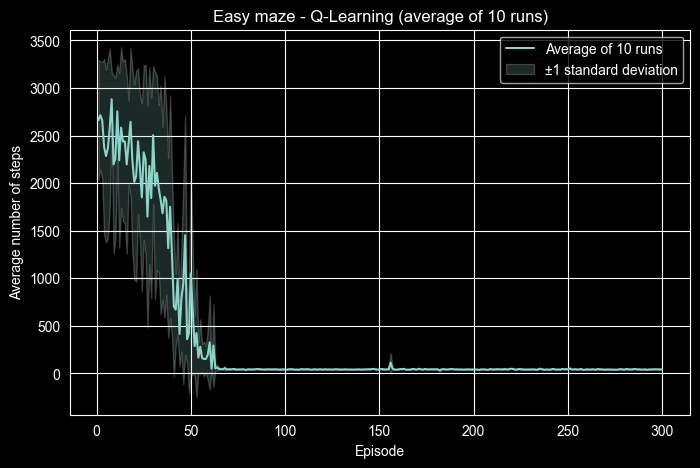

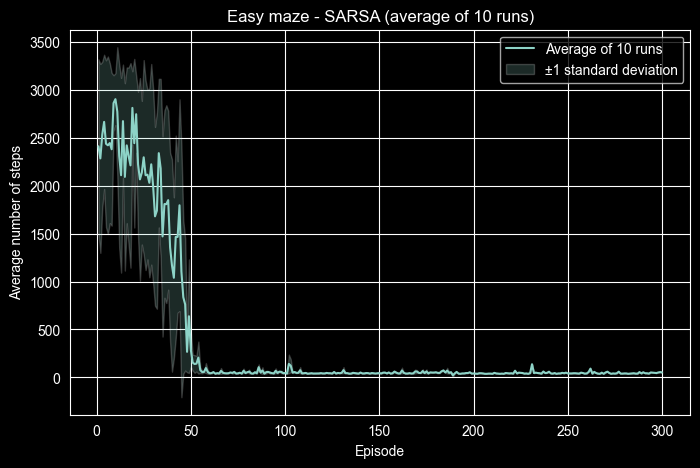

In [9]:
def train_one_run(maze_path, reward_x, reward_y, start_x, start_y,
                  algorithm="qlearning",
                  n_episodes=300,
                  max_steps=1000,
                  max_total_steps=30000,
                  eps=0.1,
                  params=None):

    if params is None:
        params = {"lr": 0.7, "gamma": 0.9}

    maze = Maze(maze_path)
    maze.set_reward(x=reward_x, y=reward_y, reward=10)
    maze.set_terminal(x=reward_x, y=reward_y)

    agent = Agent(start_x=start_x, start_y=start_y)
    states = maze.get_all_states()
    actions = [Action(a) for a in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)

    if algorithm == "qlearning":
        learner = QLearning(q_table, params)
    elif algorithm == "sarsa":
        learner = SARSA(q_table, params)
    else:
        raise ValueError("algorithm must be 'qlearning' or 'sarsa'")

    episode_lengths = []
    total_steps = 0

    for _ in range(n_episodes):
        if total_steps >= max_total_steps:
            break

        agent.reset()
        done = False

        if algorithm == "sarsa":
            action = exploration_strategy.e_greedy(agent, maze, eps)

        while not done and agent.nr_of_actions_since_reset < max_steps:
            if total_steps >= max_total_steps:
                break

            state = agent.get_state(maze)

            if algorithm == "qlearning":
                action = exploration_strategy.e_greedy(agent, maze, eps)

            next_state, reward, done = agent.step(action, maze)
            total_steps += 1

            possible_actions = agent.get_valid_actions(maze)

            if algorithm == "qlearning":
                learner.learn(possible_actions, state, action, next_state, reward, done)

            else:
                if done:
                    next_action = None
                else:
                    next_action = exploration_strategy.e_greedy(agent, maze, eps)

                learner.learn(state, action, next_state, next_action, reward, done)
                action = next_action

        episode_lengths.append(agent.nr_of_actions_since_reset)

    return episode_lengths


def average_learning_runs(maze_path, reward_x, reward_y, start_x, start_y,
                          algorithm,
                          n_runs=10,
                          n_episodes=300,
                          max_steps=1000,
                          max_total_steps=30000,
                          eps=0.1,
                          params=None):

    all_lengths = []

    for _ in range(n_runs):
        lengths = train_one_run(
            maze_path=maze_path,
            reward_x=reward_x,
            reward_y=reward_y,
            start_x=start_x,
            start_y=start_y,
            algorithm=algorithm,
            n_episodes=n_episodes,
            max_steps=max_steps,
            max_total_steps=max_total_steps,
            eps=eps,
            params=params
        )
        all_lengths.append(lengths)

    max_len = max(len(run) for run in all_lengths)
    padded = np.full((n_runs, max_len), np.nan)

    for i, run in enumerate(all_lengths):
        padded[i, :len(run)] = run

    mean_lengths = np.nanmean(padded, axis=0)
    std_lengths = np.nanstd(padded, axis=0)

    return mean_lengths, std_lengths


def plot_learning_curve(mean_lengths, std_lengths, title):
    episodes = np.arange(1, len(mean_lengths) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(episodes, mean_lengths, label="Average of 10 runs")
    plt.fill_between(
        episodes,
        mean_lengths - std_lengths,
        mean_lengths + std_lengths,
        alpha=0.2,
        label="±1 standard deviation"
    )
    plt.xlabel("Episode")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


params = {"lr": 0.7, "gamma": 0.9}

# Toy maze - Q-Learning
toy_q_mean, toy_q_std = average_learning_runs(
    maze_path="./../data/toy_maze.txt",
    reward_x=9,
    reward_y=9,
    start_x=0,
    start_y=0,
    algorithm="qlearning",
    n_runs=10,
    n_episodes=300,
    max_steps=1000,
    max_total_steps=30000,
    eps=0.1,
    params=params
)

plot_learning_curve(
    toy_q_mean,
    toy_q_std,
    "Toy maze - Q-Learning (average of 10 runs)"
)

# Toy maze - SARSA
toy_s_mean, toy_s_std = average_learning_runs(
    maze_path="./../data/toy_maze.txt",
    reward_x=9,
    reward_y=9,
    start_x=0,
    start_y=0,
    algorithm="sarsa",
    n_runs=10,
    n_episodes=300,
    max_steps=1000,
    max_total_steps=30000,
    eps=0.1,
    params=params
)

plot_learning_curve(
    toy_s_mean,
    toy_s_std,
    "Toy maze - SARSA (average of 10 runs)"
)

# Easy maze - Q-Learning
easy_q_mean, easy_q_std = average_learning_runs(
    maze_path="./../data/easy_maze.txt",
    reward_x=24,
    reward_y=14,
    start_x=0,
    start_y=0,
    algorithm="qlearning",
    n_runs=10,
    n_episodes=300,
    max_steps=3000,
    max_total_steps=100000,
    eps=0.1,
    params=params
)

plot_learning_curve(
    easy_q_mean,
    easy_q_std,
    "Easy maze - Q-Learning (average of 10 runs)"
)

# Easy maze - SARSA
easy_s_mean, easy_s_std = average_learning_runs(
    maze_path="./../data/easy_maze.txt",
    reward_x=24,
    reward_y=14,
    start_x=0,
    start_y=0,
    algorithm="sarsa",
    n_runs=10,
    n_episodes=300,
    max_steps=3000,
    max_total_steps=100000,
    eps=0.1,
    params=params
)

plot_learning_curve(
    easy_s_mean,
    easy_s_std,
    "Easy maze - SARSA (average of 10 runs)"
)

For this question, we ran both learning algorithms, Q-Learning and SARSA, on both mazes and plotted the average number of steps per episode over 10 runs. As in Question 4, different runs may complete a different number of episodes before reaching the total step limit. Therefore, we padded shorter runs with `NaN` values and used `np.nanmean` and `np.nanstd` to compute the average and standard deviation per episode only over the runs that actually reached that episode. The shaded region in the plots represents one standard deviation and indicates the uncertainty across runs.

Note that for the easy maze, not all runs reach the maximum number of episodes. This is because episodes are longer, causing the total step limit to be reached earlier. As a result, the x-axis is shorter for the easy maze compared to the toy maze.

We used the parameter values specified in the assignment: $\alpha = 0.7$, $\gamma = 0.9$, and $\epsilon = 0.1$. During training, the agent selected actions using the $\epsilon$-greedy strategy, meaning that it explores with probability $0.1$ and exploits the best-known action otherwise.

The results clearly show that the agent learns in all cases, since the average number of steps decreases over time.

For the toy maze, both Q-Learning and SARSA show a very rapid decrease in the number of steps within the first 30–40 episodes. After this initial phase, both curves stabilize at a low number of steps, indicating that the agent has found a near-optimal path to the goal. The variance is relatively high at the beginning, due to exploration, but quickly decreases as the agent converges to a stable policy.

For the easy maze, learning takes longer, which is expected due to the larger state space. Q-Learning shows a relatively sharp drop in the number of steps after roughly 40–50 episodes, after which it stabilizes at a low value similar to the toy maze. SARSA, on the other hand, learns more gradually and shows more variability throughout training. Even though it eventually improves, its curve is less smooth and has larger fluctuations compared to Q-Learning.

The uncertainty bands support these observations. In the early episodes, both algorithms show large variance because the agent is still exploring and its behavior is highly stochastic. As training progresses, the variance decreases for Q-Learning, indicating consistent performance across runs. For SARSA, especially in the easy maze, the variance remains relatively large for a longer period, reflecting more variability in the learned behavior.

We conclude that the agent successfully learns its environment in all cases, as evidenced by the decreasing number of steps per episode. The improvement compared to Question 4 is due to the fact that the q-values are now updated after each transition, allowing the agent to learn which actions lead more efficiently to the goal.

#### Question 7

From the results in Question 6, we observe clear differences between Q-Learning and SARSA in terms of both learning speed and stability.

First, Q-Learning generally learns faster than SARSA. This is especially visible in the easy maze, where Q-Learning shows a relatively sharp decrease in the number of steps after around 40–50 episodes, while SARSA improves more gradually. In the toy maze, both algorithms converge quickly, but Q-Learning still reaches a stable performance slightly faster.

Second, SARSA tends to show more variability during learning. This is particularly noticeable in the easy maze, where the SARSA curve fluctuates more and has a larger uncertainty band compared to Q-Learning. This indicates that the learned behavior is less stable across runs. Q-Learning, on the other hand, converges to a more consistent performance with smaller variance after the initial learning phase.

These differences can be explained by the update rules of the two algorithms. Q-Learning is an off-policy method and updates its q-values using the maximum possible future reward:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \big(r + \gamma \max_{a'} Q(s', a') - Q(s,a)\big)
$$

This means it assumes that the agent will always take the optimal action in the next state, even during training. As a result, Q-Learning is more optimistic and tends to learn the optimal policy faster.

In contrast, SARSA is an on-policy method and updates its q-values based on the action that is actually taken:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \big(r + \gamma Q(s', a') - Q(s,a)\big)
$$

Since the next action $a'$ is chosen according to the exploration strategy (in this case $\epsilon$-greedy), SARSA incorporates the effect of exploration into its updates. This makes it more conservative and results in slower learning and higher variability, because the updates depend on potentially suboptimal exploratory actions.

 Q-Learning performs better in terms of learning speed and stability, while SARSA learns more cautiously and is more sensitive to the exploration strategy.

### 2.2 Optimization
#### Question 8

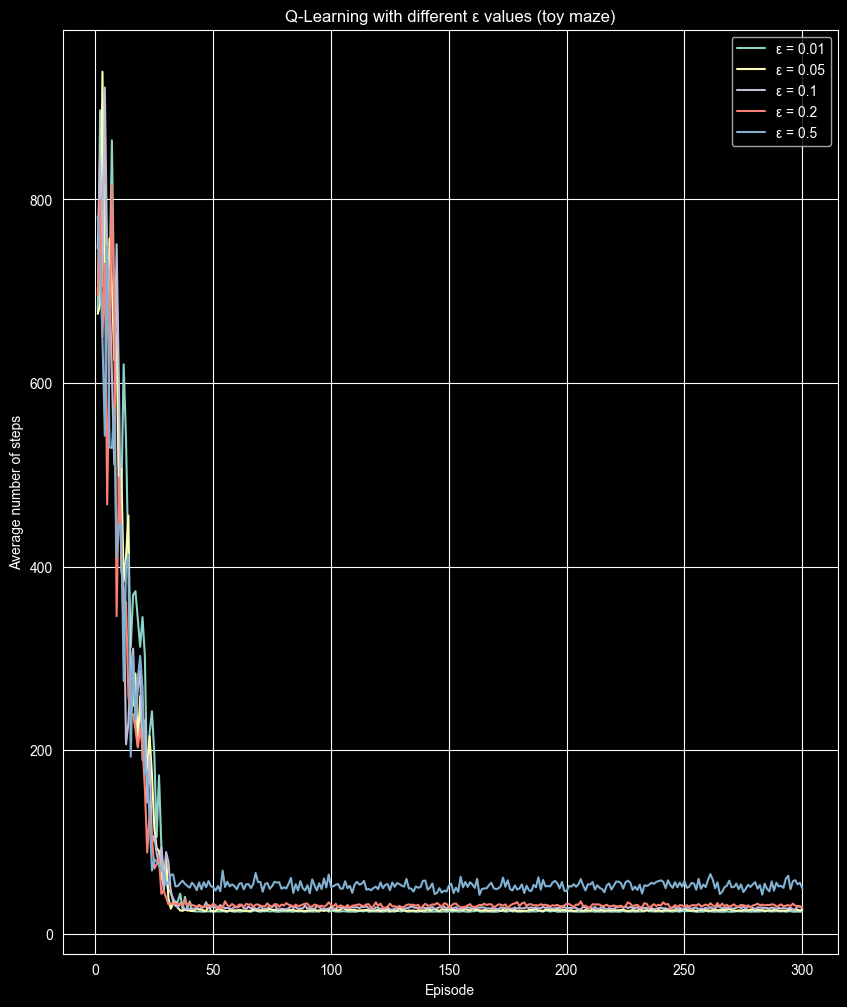

In [10]:
eps_values = [0.01, 0.05, 0.1, 0.2, 0.5]

params = {"lr": 0.7, "gamma": 0.9}

plt.figure(figsize=(10, 12))

for eps in eps_values:
    mean_lengths, std_lengths = average_learning_runs(
        maze_path="./../data/toy_maze.txt",
        reward_x=9,
        reward_y=9,
        start_x=0,
        start_y=0,
        algorithm="qlearning",
        n_runs=10,
        n_episodes=300,
        max_steps=1000,
        max_total_steps=30000,
        eps=eps,
        params=params
    )

    episodes = np.arange(1, len(mean_lengths) + 1)
    plt.plot(episodes, mean_lengths, label=f"ε = {eps}")

plt.xlabel("Episode")
plt.ylabel("Average number of steps")
plt.title("Q-Learning with different ε values (toy maze)")
plt.legend()
plt.grid(True)
plt.show()

Here, we evaluated the effect of different values of $\epsilon$ in the $\epsilon$-greedy exploration strategy using Q-Learning on the toy maze. We tested the values $\epsilon \in \{0.01, 0.05, 0.1, 0.2, 0.5\}$ and plotted the average number of steps per episode over 10 runs.

From the plot, we observe that all values of $\epsilon$ eventually lead to learning, as the average number of steps decreases rapidly in the first 30–40 episodes and then stabilizes. However, there are clear differences in both learning speed and final performance depending on the value of $\epsilon$.

For very low values of $\epsilon$ (e.g. $\epsilon = 0.01$), the agent explores very little. As a result, learning is slightly slower in the beginning, because the agent does not sufficiently explore alternative paths and may take longer to discover the optimal route. However, once it has learned a good policy, the performance is quite stable and the number of steps remains low.

For moderate values such as $\epsilon = 0.05$ and $\epsilon = 0.1$, we observe the best overall performance. These values provide a good balance between exploration and exploitation: the agent explores enough to discover efficient paths early on, but also exploits learned knowledge sufficiently to converge quickly and maintain a low number of steps. The curves for these values are both low and stable after convergence.

For higher values of $\epsilon$ (e.g. $\epsilon = 0.2$ and especially $\epsilon = 0.5$), the agent explores more aggressively. While this can help in the early stages, it leads to worse final performance. Even after learning, the agent continues to take random actions frequently, which prevents it from consistently following the optimal path. This is visible in the plot, where higher $\epsilon$ values result in a higher average number of steps after convergence and more fluctuation in the curve.

In summary, there is a clear trade-off in choosing $\epsilon$. Too little exploration slows down learning, while too much exploration prevents the agent from fully exploiting what it has learned. In our experiments, intermediate values such as $\epsilon = 0.05$ or $\epsilon = 0.1$ provide the best balance and lead to the most efficient performance.

#### Question 9

There is a clear trade-off between high and low values of $\epsilon$ in the $\epsilon$-greedy exploration strategy.

For low values of $\epsilon$, the agent mainly exploits its current knowledge and only explores rarely. This leads to more stable behavior and better performance once a good policy has been found, because the agent consistently follows the best-known actions. However, the downside is that learning can be slower, especially in the early stages, since the agent may not explore enough to discover better paths. In extreme cases, the agent can get stuck in suboptimal policies due to insufficient exploration.

For high values of $\epsilon$, the agent explores more frequently by taking random actions. This increases the chance of discovering better paths early in training and can speed up initial learning. However, even after learning, the agent continues to explore, which leads to less stable behavior and a higher number of steps per episode. As a result, the final performance is typically worse compared to lower $\epsilon$ values.

In summary, low $\epsilon$ values favour exploitation and stable performance but risk insufficient exploration, while high $\epsilon$ values favour exploration but reduce the ability to consistently follow the optimal policy. A moderate value of $\epsilon$ provides a balance between these two effects.


#### Question 10

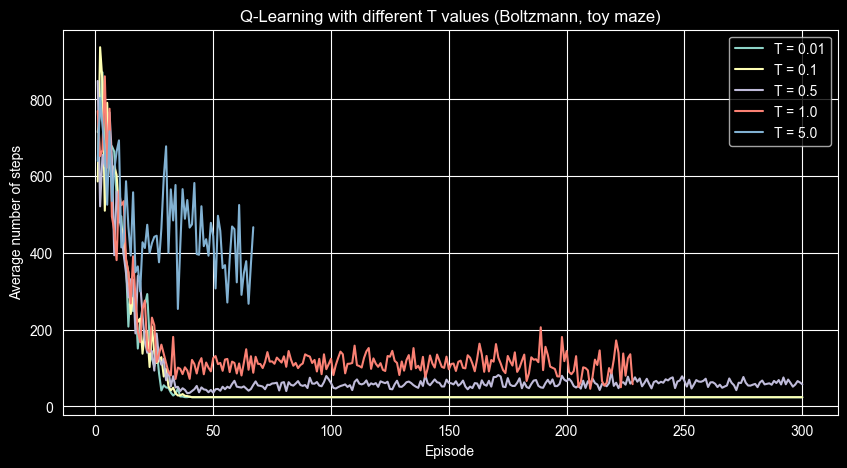

In [11]:
T_values = [0.01, 0.1, 0.5, 1.0, 5.0]

params = {"lr": 0.7, "gamma": 0.9}

plt.figure(figsize=(10, 5))

for T in T_values:
    # temporarily use Boltzmann instead of e-greedy
    def train_boltzmann_run():
        maze = Maze("./../data/toy_maze.txt")
        maze.set_reward(x=9, y=9, reward=10)
        maze.set_terminal(x=9, y=9)

        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(a) for a in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)
        learner = QLearning(q_table, params)

        episode_lengths = []
        total_steps = 0

        for _ in range(300):
            if total_steps >= 30000:
                break

            agent.reset()
            done = False

            while not done and agent.nr_of_actions_since_reset < 1000:
                if total_steps >= 30000:
                    break

                state = agent.get_state(maze)
                action = exploration_strategy.boltzmann(agent, maze, temperature=T)

                next_state, reward, done = agent.step(action, maze)
                total_steps += 1

                possible_actions = agent.get_valid_actions(maze)
                learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_lengths.append(agent.nr_of_actions_since_reset)

        return episode_lengths

    all_runs = [train_boltzmann_run() for _ in range(10)]

    max_len = max(len(run) for run in all_runs)
    padded = np.full((10, max_len), np.nan)

    for i, run in enumerate(all_runs):
        padded[i, :len(run)] = run

    mean_lengths = np.nanmean(padded, axis=0)

    episodes = np.arange(1, len(mean_lengths) + 1)
    plt.plot(episodes, mean_lengths, label=f"T = {T}")

plt.xlabel("Episode")
plt.ylabel("Average number of steps")
plt.title("Q-Learning with different T values (Boltzmann, toy maze)")
plt.legend()
plt.grid(True)
plt.show()

Here, we investigated the effect of different values of the temperature parameter $T$ in the Boltzmann exploration strategy using Q-Learning on the toy maze. We tested the values $T \in \{0.01, 0.1, 0.5, 1.0, 5.0\}$ and plotted the average number of steps per episode over 10 runs.

From the plot, we observe that all values of $T$ eventually lead to learning, as the number of steps decreases in the early episodes. However, there are clear differences in both learning speed and final performance depending on the temperature.

For very low values of $T$ (e.g. $T = 0.01$), the agent behaves almost greedily. This results in fast convergence and low final number of steps, since the agent quickly exploits the best actions. However, similar to low $\epsilon$ values, the lack of exploration may limit the ability to discover better paths in more complex environments.

For moderate values such as $T = 0.1$ and $T = 0.5$, the agent shows a good balance between exploration and exploitation. These values lead to relatively fast learning and stable performance after convergence. The curves are low and consistent, indicating that the agent is able to both explore sufficiently and exploit effectively.

For higher values of $T$ (e.g. $T = 1.0$ and especially $T = 5.0$), the agent explores much more. This results in slower convergence and worse final performance. In particular, for $T = 5.0$, the agent behaves almost randomly for a long time, leading to high variance and a much higher number of steps in the early and middle stages of training. Even after learning, performance remains worse compared to lower values of $T$.

In summary, the temperature parameter $T$ controls the level of randomness in action selection. Low values favour exploitation, while high values favour exploration. As with $\epsilon$ in the $\epsilon$-greedy strategy, a moderate value of $T$ provides the best trade-off, resulting in efficient and stable learning.

#### Question 11

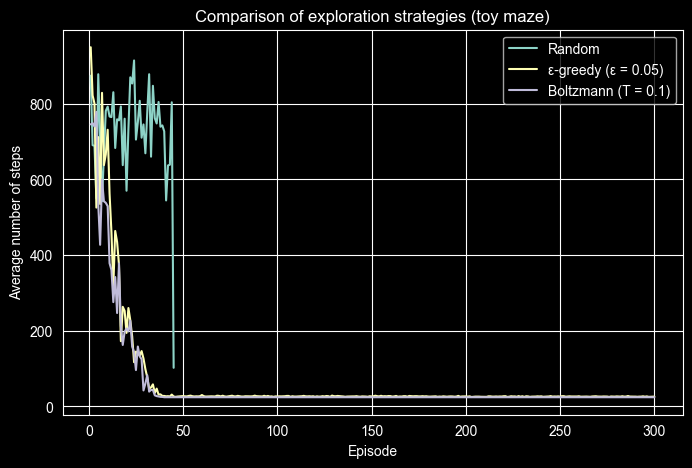

In [13]:
params = {"lr": 0.7, "gamma": 0.9}

def train_random_run():
    maze = Maze("./../data/toy_maze.txt")
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    agent = Agent(start_x=0, start_y=0)
    states = maze.get_all_states()
    actions = [Action(a) for a in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, params)

    episode_lengths = []
    total_steps = 0

    for _ in range(300):
        if total_steps >= 30000:
            break

        agent.reset()
        done = False

        while not done and agent.nr_of_actions_since_reset < 1000:
            if total_steps >= 30000:
                break

            state = agent.get_state(maze)
            action = exploration_strategy.random(agent, maze)

            next_state, reward, done = agent.step(action, maze)
            total_steps += 1

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

        episode_lengths.append(agent.nr_of_actions_since_reset)

    return episode_lengths


def train_eps_run(eps):
    return train_one_run(
        maze_path="./../data/toy_maze.txt",
        reward_x=9,
        reward_y=9,
        start_x=0,
        start_y=0,
        algorithm="qlearning",
        n_episodes=300,
        max_steps=1000,
        max_total_steps=30000,
        eps=eps,
        params=params
    )


def train_boltzmann_run(T):
    maze = Maze("./../data/toy_maze.txt")
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    agent = Agent(start_x=0, start_y=0)
    states = maze.get_all_states()
    actions = [Action(a) for a in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, params)

    episode_lengths = []
    total_steps = 0

    for _ in range(300):
        if total_steps >= 30000:
            break

        agent.reset()
        done = False

        while not done and agent.nr_of_actions_since_reset < 1000:
            if total_steps >= 30000:
                break

            state = agent.get_state(maze)
            action = exploration_strategy.boltzmann(agent, maze, temperature=T)

            next_state, reward, done = agent.step(action, maze)
            total_steps += 1

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

        episode_lengths.append(agent.nr_of_actions_since_reset)

    return episode_lengths


def average_runs_from_function(run_function, n_runs=10):
    all_runs = [run_function() for _ in range(n_runs)]

    max_len = max(len(run) for run in all_runs)
    padded = np.full((n_runs, max_len), np.nan)

    for i, run in enumerate(all_runs):
        padded[i, :len(run)] = run

    mean_lengths = np.nanmean(padded, axis=0)
    return mean_lengths


random_mean = average_runs_from_function(train_random_run, n_runs=10)
egreedy_mean = average_runs_from_function(lambda: train_eps_run(0.05), n_runs=10)
boltzmann_mean = average_runs_from_function(lambda: train_boltzmann_run(0.1), n_runs=10)

plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(random_mean) + 1), random_mean, label="Random")
plt.plot(np.arange(1, len(egreedy_mean) + 1), egreedy_mean, label="ε-greedy (ε = 0.05)")
plt.plot(np.arange(1, len(boltzmann_mean) + 1), boltzmann_mean, label="Boltzmann (T = 0.1)")

plt.xlabel("Episode")
plt.ylabel("Average number of steps")
plt.title("Comparison of exploration strategies (toy maze)")
plt.legend()
plt.grid(True)
plt.show()

Using the insights from tuning $\epsilon$ and $T$, we compared the performance of three exploration strategies: random exploration, $\epsilon$-greedy (with $\epsilon = 0.05$), and Boltzmann exploration (with $T = 0.1$).

From the plot, we observe that the $\epsilon$-greedy and Boltzmann strategies perform significantly better than random exploration. Both $\epsilon$-greedy and Boltzmann show a rapid decrease in the number of steps during the first 30–40 episodes and quickly converge to a low and stable number of steps. In contrast, random exploration performs very poorly: the number of steps remains high and highly variable, and the agent does not show consistent improvement over time.

Between $\epsilon$-greedy and Boltzmann, the performance is quite similar, but $\epsilon$-greedy appears to perform slightly better in terms of stability and final number of steps. Its curve is slightly lower and smoother after convergence, indicating that the agent is more consistent in following the optimal path.

These differences can be explained by how each exploration strategy selects actions. Random exploration selects actions uniformly at random, meaning the agent never exploits its learned knowledge. As a result, even though Q-values are updated, the agent does not consistently follow better actions, which prevents effective learning in practice.

The $\epsilon$-greedy strategy balances exploration and exploitation by selecting a random action with probability $\epsilon$ and the best-known action otherwise. This allows the agent to discover good paths early on while still exploiting them once they are learned. This balance leads to efficient and stable learning.

Boltzmann exploration also balances exploration and exploitation, but does so in a probabilistic way based on the q-values. Actions with higher q-values are more likely to be chosen, but suboptimal actions can still be selected with some probability. While this provides a more nuanced exploration mechanism, it can introduce slightly more randomness compared to $\epsilon$-greedy, which may explain the small differences in stability observed in the plot.

In summary, $\epsilon$-greedy performs best in our experiments due to its simple and effective balance between exploration and exploitation. Boltzmann exploration performs similarly but is slightly less stable, while random exploration performs worst because it does not exploit learned knowledge.

#### Question 12

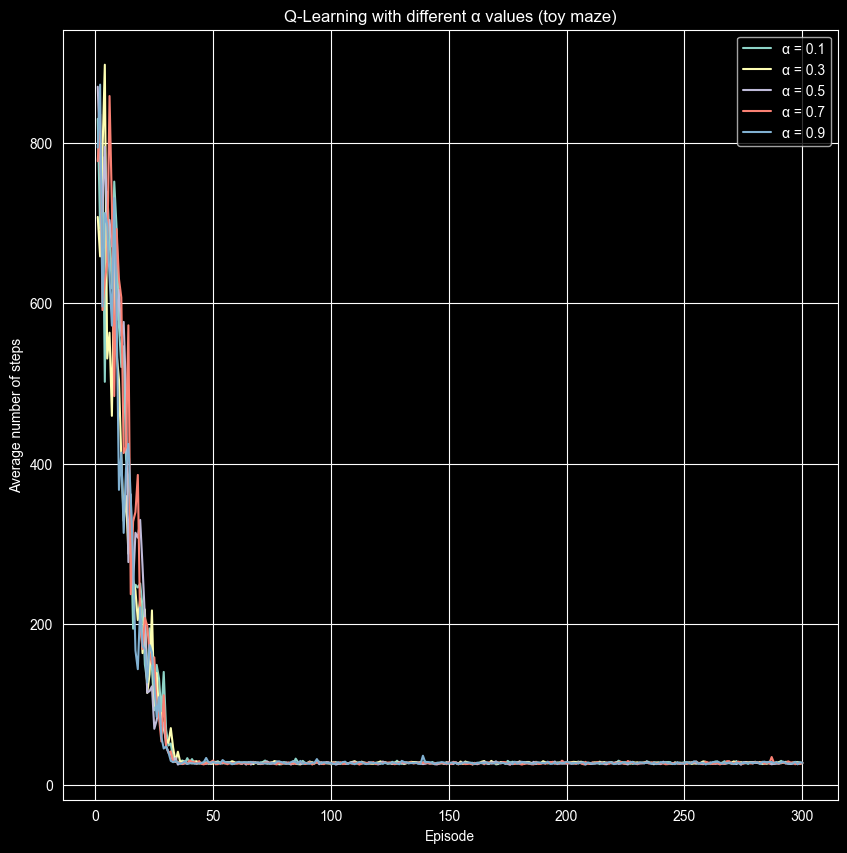

In [15]:
alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]

gamma = 0.9

plt.figure(figsize=(10, 10))

for alpha in alpha_values:
    params = {"lr": alpha, "gamma": gamma}

    mean_lengths, std_lengths = average_learning_runs(
        maze_path="./../data/toy_maze.txt",
        reward_x=9,
        reward_y=9,
        start_x=0,
        start_y=0,
        algorithm="qlearning",
        n_runs=10,
        n_episodes=300,
        max_steps=1000,
        max_total_steps=30000,
        eps=0.1,
        params=params
    )

    episodes = np.arange(1, len(mean_lengths) + 1)
    plt.plot(episodes, mean_lengths, label=f"α = {alpha}")

plt.xlabel("Episode")
plt.ylabel("Average number of steps")
plt.title("Q-Learning with different α values (toy maze)")
plt.legend()
plt.grid(True)
plt.show()

Here, we investigated the effect of different values of the learning rate $\alpha$ in Q-Learning on the toy maze. We tested the values $\alpha \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$ and plotted the average number of steps per episode over 10 runs.

From the plot, we observe that all values of $\alpha$ lead to successful learning. In all cases, the number of steps decreases rapidly in the first 30–40 episodes and stabilizes at a low value. This indicates that the agent is able to learn an efficient policy regardless of the exact value of $\alpha$ in this relatively simple environment.

However, there are small differences in learning behavior depending on the value of $\alpha$. Lower values of $\alpha$ (e.g. $\alpha = 0.1$) tend to produce slightly smoother and more stable learning curves, because updates to the q-values are more gradual. This leads to more consistent learning, but can slow down the speed at which the agent adapts to new information.

Higher values of $\alpha$ (e.g. $\alpha = 0.9$) result in larger updates to the q-values. This can speed up learning in the early stages, but may also introduce more variability, since the agent places more weight on recent experiences. In practice, this can lead to slightly noisier curves, although in this experiment the effect is not very pronounced.

Intermediate values such as $\alpha = 0.5$ or $\alpha = 0.7$ provide a good balance between stability and learning speed. These values allow the agent to update its estimates efficiently while still maintaining relatively stable learning behavior.

In summary, the learning rate $\alpha$ controls how strongly new information influences the q-values. Low values lead to slow but stable learning, while high values lead to faster but potentially less stable updates. In this simple environment, all tested values perform well, but moderate values offer the best balance.

### 2.3 Introducing More Rewards
#### Question 13



_Put your code blocks above (if any) and write your answer here._

#### Question 14



_Put your code blocks above (if any) and write your answer here._

#### Question 15



_Put your code blocks above (if any) and write your answer here._

#### Question 16



_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

When using an algorithm that is greedy with its action selection, we risk getting stuck in a sub-optimal policy. This is due to the lack of the exploration of the environment, since such an agent always chooses the action with the highest estimated value based on the current knowledge. But that means that the agent ignores actions that might lead to a bigger reward in the long run if their current estimates are lower or unknown. 

An example for this can be choosing a route to university. Say there are two routes: route 1, which has a shorter path, but includes a hole in the ground, and route 2: a longer path around the hole. Using the greedy algorithm, the agent will choose route 1, since the total distance is way shorter than with route 2, but it turns out that route 2 is actually quicker, since you have to get of the bike and walk around the hole, which ends up taking more time, but the agent doesn't know that yet, so it chooses the sub-optimal path.

#### Question 18

When using RL, reward functions can cause societal problems when the agent has a misalignment between the reward provided to the agent and what the actual goal of the problem is. This is because the agent lacks the human intention and just bases everything on the mathematical rewards.

An example of this is when we let AI run a traffic system. The intended goal of this is to create an infrastructure that allows traffic to smoothly run and getting people to their destination as quick as possible. The agent is given a positive reward for every car that passes through an intersection, and it is given a negative reward when the total cumulative waiting time for all the vehicles in the city is high.

When the agent is learning, it might find that the most effective way to minimize the total waiting time is just to keep all lights permanently green at high-volume roads or highways, while keeping a constant red light at low-volume roads. The problem that is caused by this is that the people driving on low-volume roads have to wait a long time as opposed to people using the highway, which is not the fairness that humans intended. The goal was to get *all* people to their destination as quick as possible, not just as many people as possible, without keeping track of people who are trapped because of it.

#### Question 19

A possible solution for this problem could be having humans check on the agents model every once in a while. The agent is trained using a learned reward model. Then, humans are presented with multiple behaviours of the agent which they will rank, ensuring that the right intention remains. This can even be repeated a few time to make sure the agent really does what it is supposed to do and doesn't end up in a solution that is mathematically optimal, but has the wrong intentions. This used in practice, called Reinforcement Learning from Human Feedback (RLHF).

### 3.2 Pen and Paper
#### Question 20

There are two variables that define the states: location and inventory
Locations: Entrance (E), Aisle (A), Checkout (C)
Inventory: Empty (0), Apples (Ap), 1 box of berries (B1), 2 boxes of berries (B2)


#### States:
S0: (E, 0) - Starting state
S1: (A, 0)
S2: (A, Ap)
S3: (A, B1)
S4: (A, B2)
S5: (C, 0)
S6: (C, Ap)
S7: (C, B1)
S8: (C, B2)
Terminal: reached after pay action

 
### We have different kind of transitions:
#### Movement actions (all forward/back actions):
(E, 0) -> (A, 0) [p=0.9, r=0] (forward)
(E, 0) -> (E, 0) [p=0.1, r=-1] (stays in same position)

(A, 0) -> (E, 0) [p=0.9, r=0] (back)
(A, 0) -> (A, 0) [p=0.1, r=-1] (stays in same position)

(A, Ap) -> (C, Ap) [p=0.9, r=0]
(A, Ap) -> (A, Ap) [p=0.1, r=-1]

(A, B1) -> (C, B1) [p=0.9, r=0]
(A, B1) -> (A, B1) [p=0.1, r=-1]

(A, B2) -> (C, B2) [p=0.9, r=0]
(A, B2) -> (A, B2) [p=0.1, r=-1]

(C, Ap) -> (A, Ap) [p=0.9, r=0]
(C, Ap) -> (C, Ap) [p=0.1, r=-1]

(C, B1) -> (A, B1) [p=0.9, r=0]
(C, B1) -> (C, B1) [p=0.1, r=-1]

(C, B2) -> (A, B2) [p=0.9, r=0]
(C, B2) -> (C, B2) [p=0.1, r=-1]


#### Grabbing items:
(A, 0) -> (A, Ap) [p=1.0, r=0] (pick up apples)
(A, 0) -> (A, B1) [p=1.0, r=0] (pick up first box of berries)
(A, B1) -> (A, B2) [p=0.8, r=0] (pick up second box of berries)
(A, B1) -> (A, B1) [p=0.2, r=-2] (failure picking up second box)


#### Payment: (only at checkout)
(C, 0) -> Terminal [r=0]
(C, Ap) -> Terminal [r=5]
(C, B1) -> Terminal [r=3]
(C, B2) -> Terminal [r=10]

#### Question 21

#### Tabular representation: 
| State ($s$) | Description                  | Action $\pi(s)$          | $v_0(s)$ |
|:------------|:-----------------------------|:-------------------------|:---------|
| (A, 0)      | Aisle, Empty basket          | Pick up berries          | 0 |
| (A, B1)     | Aisle, 1 box of berries      | Pick up berries          | 0 |
| (A, B2)     | Aisle, 2 boxes of berries    | Forward to checkout      | 0 |
| (C, B2)     | Checkout, 2 boxes of berries | Pay                      | 0 |
 
We set $v_0(s)$ = 0 since it is the initialization.

#### Calculating $v_1(s)$
When calculating $v_1(s)$, we know that $v_0(s)$ = 0 so the calculation becomes 'Probability x Reward'.
State (A, 0):
Probability 100% of 0 reward: 
$v_1(A, 0)$ = 1.0 x 0 = 0

State (A, B1):
Probability 80% of 0 reward, probability 20% of -2 penalty:
$v_1(A, B1)$ = (0.8 x 0) + (0.2 x -2) = -0.4

State (A, B2): 
Probability 90% of 0 reward, probability 10% of -1 penalty:
$v_1(A, B2)$ = (0.9 x 0) + (0.1 x -1) = -0.1

State(C, B2):
Probability 100% of 10 reward:
$v_1(C, B2)$ = 1.0 x 10 = 10

#### Calculating $v_2(s)$
We now factor in the discounted future value ($\gamma$). We use $\gamma$ = 0.9

State (A, 0):
Success rate of 100%. It moves to (A, B1). We know $v_1(A, B1)$ = -0.4:
$v_2(A, 0)$ = 1.0 x [0 + (0.9 x -0.4)] = -0.36

State (A, B1):
Success rate of 80% and a failure rate of 20%. 
For success, it moves to (A, B2). We know $v_1(A, B2)$ = -0.1:
value = 0.8 x [0 + (0.9 x -0.1)] = -0.072
For failure, it stays at (A, B1). We know $v_1(A, B1)$ = -0.4:
value = 0.2 x [-2 + (0.9 x -0.4)] = -0.472
So:
$v_2(A, B1)$ = -0.072 - 0.472 = -0.544

State (A, B2):
Success rate of 90% and a failure rate of 10%. 
For success, it moves to (C, B2). We know $v_1(C, B2)$ = 10:
value = 0.9 x [0 + (0.9 x 10)] = 8.1
For failure, it stays at (A, B2). We know $v_1(A, B2)$ = -0.1
value = 0.1 x [-1 + (0.9 x -0.1)] = -0.109
So:
$v_2(A, B2) = 8.1 - 0.109 = 7.991

For state (C, B2) the value remains 10 since there is no action to be taken after this (it leads to termination).

#### Question 22

To find the optimal policy for the robot we would have to calculate and compare the expected values of the different paths. There are three different goals: picking up apples, picking up one box of berries and picking up two boxes of berries. For each of these we should calculate the expected returns and then compare these to the other policies, considering not only what the highest number is but also what the risks are (spilling and not moving). The policy with the highest mathematical average from the starting state is the optimal policy. 

### 3.3 Division of Work

#### Question 23




|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References



**If you made use of any non-course resources, cite them below.**

### Use of AI
In question 4 AI was used as assinstance to make the graphs more informative